In [1]:
from impact import Impact

from distgen import Generator

import numpy as np

import os 

ROOT = os.environ['LCLS_LATTICE']

In [2]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

# cu_inj Impact-T

In [3]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/ImpactT.yaml')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


In [4]:
I = Impact.from_yaml(ifile)

In [5]:
for ele in I.lattice:
    if ele['type'] != 'quadrupole':
        continue
    name = ele['name']
    L = ele['L']
    L_eff = ele['L_effective']
    zedge = ele['zedge']
    sbeg = zedge + (L-L_eff)/2
    send = zedge + L - (L-L_eff)/2
    offset = 2017.91148
    print(f'{name} {L:10} {L_eff:10} {sbeg:10.6} {send:10.6}')

SQ01       0.36       0.21    0.09101    0.30101
CQ01       0.36       0.21    0.09101    0.30101
QA01      0.204      0.108    4.80093    4.90893
QA02      0.204      0.108    5.12931    5.23731
QE01      0.204      0.108    8.44005    8.54805
QE02      0.204      0.108    8.84156    8.94956
QE03      0.204      0.108    11.5172    11.6252
QE04      0.204      0.108    11.9236    12.0316


In [6]:
from impact.lattice import ele_line
ele_line(I.lattice[-1])

'0 0 0 -99 16.5 0.0 16.5 /!name:stop_1'

# Check Energies

In [7]:
from impact.autophase import autophase_and_scale

from pmd_beamphysics import single_particle

P0 = single_particle(pz=1e-15, z=1e-15)

# Energy out of the gun
I.track(P0, s = 0.5)['mean_energy']

6000000.000536164

In [8]:
I.track(P0, s = I['L0A_exit']['s'])['mean_energy']

63999925.01489361

In [9]:
I.track(P0, s = I['OTR2']['s'])['mean_energy']

134999237.91338605

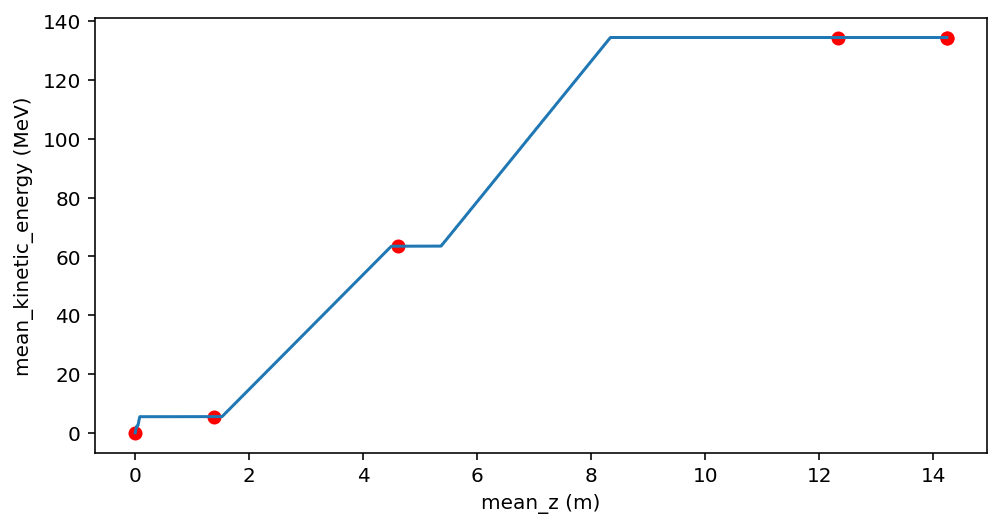

In [10]:
I.plot('mean_kinetic_energy')

In [11]:
I.particles

{'initial_particles': <ParticleGroup with 1 particles at 0x7f97b50f1890>,
 'final_particles': <ParticleGroup with 1 particles at 0x7f97b99b6410>,
 'YAG02': <ParticleGroup with 1 particles at 0x7f97b99efe50>,
 'YAG03': <ParticleGroup with 1 particles at 0x7f97b07af790>,
 'OTR1': <ParticleGroup with 1 particles at 0x7f97b99b0d10>,
 'OTR2': <ParticleGroup with 1 particles at 0x7f97b8b00350>}

# Gun Phasing

In [12]:
autophase_and_scale(I, phase_ele_name='GUN_phase', phase_attribute='dtheta0_deg', scale_ele_name='GUN_scale', scale_attribute='voltage', target=6e6, scale_range=(4e6, 6e6), metric='mean_energy', initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing GUN_phase by changing dtheta0_deg
Scaling GUN_scale by changing voltage
Bounds: 0.0, 0.15 m
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 180, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.3187678203780315 MeV
Phase: 264.9844890561601, Scale: 4000000.0, 0.0 M
Phase: 42.49224000000004, Scale: 4000000.0, 3.3187678203780315 MeV
Phase: 42.49223440298533, Scale: 4000000.0, 3.318768120421592 MeV
Phase: 264.9844709438398, Scale: 4000000.0, 0.0 M
Phase: 222.49225347495212, Scale: 4000000.0, 0.0 M
Phase: 127.47670402554945, Scale: 4000000.0, 0.0 M
Phase: 333.7383616878283, Scale: 4000000.0, 4.4316522234874265 MeV
Phase: 291.24613071818885, Scale: 4000000.0, 0.0 M
Phase: 3.4333459097979357e-06, Scale: 4000000.0, 4.466519626613704 Me

(0.07752968240851033, 5489005.283048258)

# L0A, L0B

In [13]:
# L0A
autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=False)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48506805535 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit
Default brent2 algorithm
Phase: 180, Scale: 10000000.0, 5.6715607265605295 MeV
Phase: 180, Scale: 10000000.0, 5.6715607265605295 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368928888672007 MeV
Phase: 264.9844890561601, Scale: 10000000.0, 7.73755563577382 MeV
Phase: 42.49224000000004, Scale: 10000000.0, 12.368928888672007 MeV
Phase: 42.49223440298533, Scale: 10000000.0, 12.368929700629458 MeV
Phase: 264.9844709438398, Scale: 10000000.0, 7.737553425199242 MeV
Phase: 222.49226875848944, Scale: 10000000.0, 4.7617552786469535 MeV
Phase: 127.47670402554945, Scale: 10000000.0, 4.123917953143542 MeV
Phase: 333.7383675256199, Scale: 10000000.0, 15.4047

(0.013328522447864088, 57999993.69314491)

In [14]:
ps_f, Itest = autophase_and_scale(I, phase_ele_name='L0A_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0A_scale', scale_attribute='voltage',
                    target=64e6, scale_range=(10e6, 100e6), initial_particles=P0, verbose=True, debug=True)

Copied initial Impact object. 
Phasing L0A_phase by changing dtheta0_deg
Scaling L0A_scale by changing voltage
Bounds: 1.485, 4.527856 m
Tracking initial particles to s = 1.485
Initial particle:  1.48506805535 6000000.000077931
Disabling GUN
Disabling SOL1
Disabling L0B_entrance
Disabling L0B_body_1
Disabling L0B_body_2
Disabling L0B_exit


Phase: -2.0, Scale: 58000000.0, 63.964905843622624 MeV
Phase: -1.5, Scale: 58000000.0, 63.980263052970166 MeV
Phase: -1.0, Scale: 58000000.0, 63.99123463655892 MeV
Phase: -0.5, Scale: 58000000.0, 63.99781509038551 MeV
Phase: 0.0, Scale: 58000000.0, 63.9999992467347 MeV
Phase: 0.5, Scale: 58000000.0, 63.99778227060262 MeV
Phase: 1.0, Scale: 58000000.0, 63.9911596612299 MeV
Phase: 1.5, Scale: 58000000.0, 63.98012724903597 MeV
Phase: 2.0, Scale: 58000000.0, 63.96468119664131 MeV


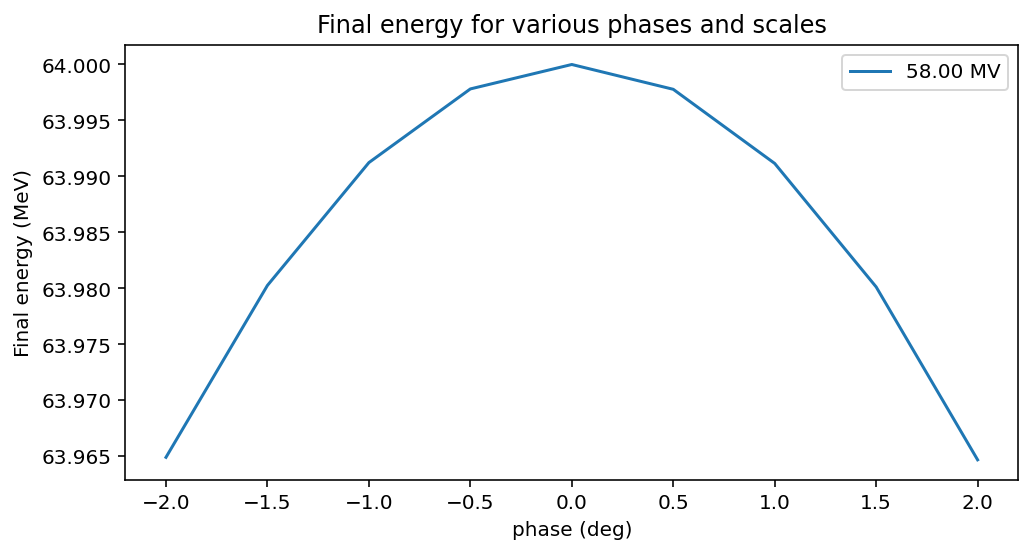

In [15]:
# Phases to try
ptry = np.linspace(-2, 2, 9)

# scales to try
sc = 58e6
res = np.array([ps_f(p, sc)/1e6 for p in ptry])
plt.plot(ptry, res, label=f'{sc/1e6:0.2f} MV')
plt.title('Final energy for various phases and scales')
plt.ylabel('Final energy (MeV)')
plt.xlabel('phase (deg)')
plt.legend()

In [ ]:
# Get scale/voltage factor
30048347.359377533/(64e6 - 6e6) * np.array( [0.86571945106805, 1, 1, 0.86571945106805])

In [16]:
autophase_and_scale(I, phase_ele_name='L0B_phase', phase_attribute='dtheta0_deg', scale_ele_name='L0B_scale', scale_attribute='voltage', target=135e6, scale_range=(50e6, 80e6), initial_particles=P0, verbose=True)

Copied initial Impact object. 
Phasing L0B_phase by changing dtheta0_deg
Scaling L0B_scale by changing voltage
Bounds: 5.328756, 8.371612 m
Tracking initial particles to s = 5.328756
Initial particle:  5.32873748163 63999920.38942378
Disabling GUN
Disabling SOL1
Disabling L0A_entrance
Disabling L0A_body_1
Disabling L0A_body_2
Disabling L0A_exit
Default brent2 algorithm
Phase: 180, Scale: 50000000.0, 13.00283666979247 MeV
Phase: 180, Scale: 50000000.0, 13.00283666979247 MeV
Phase: 42.49224000000004, Scale: 50000000.0, 101.60233904950546 MeV
Phase: 264.9844890561601, Scale: 50000000.0, 59.5918647451155 MeV
Phase: 42.49224000000004, Scale: 50000000.0, 101.60233904950546 MeV
Phase: 42.49223440298533, Scale: 50000000.0, 101.60234241698582 MeV
Phase: 264.9844709438398, Scale: 50000000.0, 59.59184871087914 MeV
Phase: 222.49225162994583, Scale: 50000000.0, 26.495339217261318 MeV
Phase: 127.47670402554945, Scale: 50000000.0, 32.8761204058588 MeV
Phase: 333.7383609830986, Scale: 50000000.0, 109.

(0.01776462632257499, 70000016.20252049)

# Integrated Solenoid field

In [17]:
from impact import  fieldmaps
import numpy as np

# Fieldmaps are stored here
I.input['fieldmaps'].keys()

dict_keys(['rfdata201', 'rfdata102', 'rfdata4', 'rfdata5', 'rfdata6', 'rfdata7'])

In [18]:
# Look at a solrf element. 
I.ele['SOL1']

{'description': 'name:SOL1',
 'original': '0.49308 0 0 105 0.0 0.0 0.0 0.0 102 0.15 0.0 0.0 0.0 0.0 0.0 0.243 /!name:SOL1',
 'L': 0.49308,
 'type': 'solrf',
 'zedge': 0.0,
 'rf_field_scale': 0.0,
 'rf_frequency': 0.0,
 'theta0_deg': 0.0,
 'filename': 'rfdata102',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0.243,
 's': 0.49308,
 'name': 'SOL1'}

In [19]:
# That data is here. 
rdfata = I.input['fieldmaps']['rfdata102']

#This will process the fieldmap to extract Ez and Bz
fmap = fieldmaps.process_fieldmap_solrf(rdfata['data'])
fmap

{'Ez': {'z0': 0.0, 'z1': 0.0, 'L': 0.0, 'fourier_coefficients': array([0.])},
 'Bz': {'z0': -0.53308,
  'z1': 0.49308,
  'L': 1.02616,
  'fourier_coefficients': array([ 7.59104159e-01,  1.86860998e-01,  2.68209187e-09, -4.75732117e-01,
          5.68488796e-09, -2.63303014e-01, -2.00685489e-10,  8.31385362e-02,
         -1.07061180e-09,  3.32147505e-02,  3.34109023e-09, -4.03166145e-03,
          2.36977653e-09,  7.55695585e-02,  7.03628508e-09,  4.05472421e-02,
         -7.93679210e-09, -2.78630279e-02, -2.80674359e-08, -1.23309101e-02,
         -1.21750197e-08, -1.11917490e-03,  2.72183881e-08, -1.76941899e-02,
          2.07775590e-08, -6.82928971e-03, -4.64611502e-09,  9.04327137e-03,
         -2.74644209e-08,  3.46208848e-03,  1.22819960e-08,  4.56318358e-04,
          2.11520498e-08,  4.27450120e-03, -2.88644504e-08,  7.52482987e-04,
         -3.59752217e-08, -2.87393685e-03,  1.26542743e-08, -8.38592686e-04,
          3.01815044e-08, -1.30737597e-04, -9.86177028e-09, -1.04357300

In [20]:
# Reconstruction function
fieldmaps.fieldmap_reconsruction(fmap['Bz'], 0)

0.006497827018878065

In [21]:
zmax = 0.49308

zlist = np.linspace(0, zmax, 1000)
fieldlist = [fieldmaps.fieldmap_reconsruction(fmap['Bz'], z) for z in zlist]

# z at max field
zlist[np.argmax(np.array(fieldlist))]

0.19496156156156158

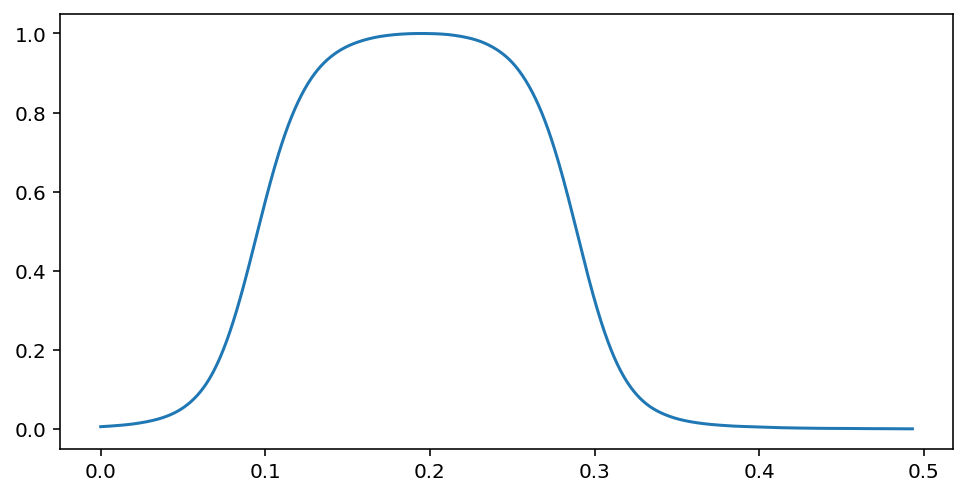

In [22]:
plt.plot(zlist, fieldlist)

In [23]:
# Integrated field (approximate)
dz = zmax/1000
BL = np.sum(fieldlist)*dz  # T*m

# 
BL * 10 # T*m -> kG*m

1.944494711358167

In [24]:
# Factor to convert BL in kG*m to Bmax in T
1/(BL * 10 )

0.5142724195436521

# Corrector Quads

In [25]:
ele = I.ele['CQ01']
ele

{'description': 'name:CQ01',
 'original': '0.36 0 0 1 0.01601  0.0 0.210 0.0254 0.0 0.0 0.0 0.0 0 /!name:CQ01',
 'L': 0.36,
 'type': 'quadrupole',
 'zedge': 0.01601,
 'b1_gradient': 0.0,
 'L_effective': 0.21,
 'radius': 0.0254,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 's': 0.37601,
 'name': 'CQ01'}

In [26]:
I['CQ01:b1_gradient']

0.0

In [27]:
# Factor to convert kG to T/m
0.1/ele['L_effective'] 

0.4761904761904762